In [1]:
from google.colab import files
files.upload()


Saving customer_churn.csv to customer_churn.csv


{'customer_churn.csv': b'CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn\r\nC00001,6,64,1540,One year,Credit Card,No,1,0\r\nC00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0\r\nC00003,27,31,1455,Two year,Credit Card,No,1,0\r\nC00004,53,29,7150,Month-to-month,Electronic Check,No,1,0\r\nC00005,16,185,1023,One year,Electronic Check,No,1,0\r\nC00006,55,44,7538,Two year,Electronic Check,No,0,0\r\nC00007,66,99,4178,Two year,Bank Transfer,No,1,0\r\nC00008,61,128,3088,Month-to-month,Bank Transfer,No,1,0\r\nC00009,64,124,7973,Month-to-month,Credit Card,No,1,0\r\nC00010,14,120,5844,One year,Bank Transfer,Yes,1,0\r\nC00011,59,57,5168,One year,Credit Card,Yes,0,0\r\nC00012,7,110,7282,Month-to-month,Electronic Check,No,1,1\r\nC00013,53,86,3438,Month-to-month,Bank Transfer,Yes,1,0\r\nC00014,8,158,6194,Month-to-month,Credit Card,No,1,1\r\nC00015,53,58,768,Month-to-month,Credit Card,Yes,1,0\r\nC00016,65,77,4071,Month-to-month,Credit Ca

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [3]:
df = pd.read_csv("customer_churn.csv")
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn
0,C00001,6,64,1540,One year,Credit Card,No,1,0
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0
2,C00003,27,31,1455,Two year,Credit Card,No,1,0
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0
4,C00005,16,185,1023,One year,Electronic Check,No,1,0


In [4]:
df.shape
df.info()
df['Churn'].value_counts()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   CustomerID        500 non-null    object
 1   Tenure            500 non-null    int64 
 2   MonthlyCharges    500 non-null    int64 
 3   TotalCharges      500 non-null    int64 
 4   Contract          500 non-null    object
 5   PaymentMethod     500 non-null    object
 6   PaperlessBilling  500 non-null    object
 7   SeniorCitizen     500 non-null    int64 
 8   Churn             500 non-null    int64 
dtypes: int64(5), object(4)
memory usage: 35.3+ KB


,count
Churn,
0,447
1,53


In [5]:
from sklearn.preprocessing import StandardScaler

X = df.drop('Churn', axis=1)
X = pd.get_dummies(X, drop_first=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_scaled.shape


(500, 508)

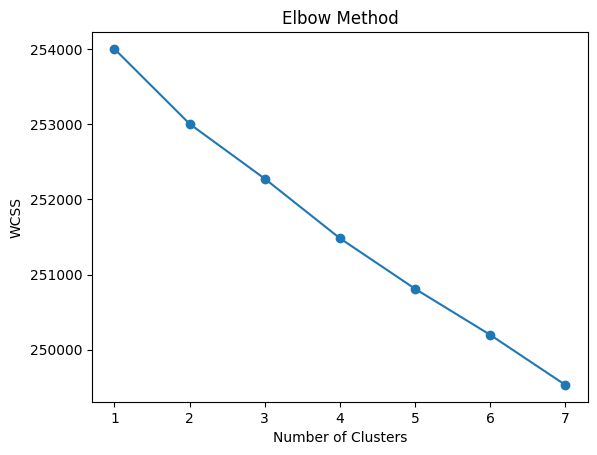

In [7]:
from sklearn.cluster import KMeans
wcss = []

for i in range(1, 8):
    kmeans = KMeans(n_clusters=i, random_state=42)
    kmeans.fit(X_scaled)
    wcss.append(kmeans.inertia_)

plt.plot(range(1, 8), wcss, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters")
plt.ylabel("WCSS")
plt.show()


In [9]:
# Final KMeans with 3 clusters
kmeans = KMeans(n_clusters=3, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Cluster label data
df['Segment'] = clusters
df.head()


,CustomerID,Tenure,MonthlyCharges,TotalCharges,Contract,PaymentMethod,PaperlessBilling,SeniorCitizen,Churn,Segment
0,C00001,6,64,1540,One year,Credit Card,No,1,0,2
1,C00002,21,113,1753,Month-to-month,Electronic Check,Yes,1,0,2
2,C00003,27,31,1455,Two year,Credit Card,No,1,0,1
3,C00004,53,29,7150,Month-to-month,Electronic Check,No,1,0,2
4,C00005,16,185,1023,One year,Electronic Check,No,1,0,0


In [10]:
df['Segment'].value_counts()


,count
Segment,
0,188
1,167
2,145


In [11]:
# Numeric columns segment-wise mean
segment_profile = df.groupby('Segment').mean(numeric_only=True)
segment_profile


,Tenure,MonthlyCharges,TotalCharges,SeniorCitizen,Churn
Segment,,,,,
0,44.622340,131.026596,4059.803191,0.276596,0.053191
1,37.473054,104.089820,4305.113772,0.491018,0.077844
2,24.958621,102.082759,4391.337931,0.793103,0.206897


## Customer Segments

**Segment 0 – Budget Conscious**
Customers with lower charges and moderate tenure.

**Segment 1 – Premium Spenders**
Customers with higher monthly charges and higher churn risk.

**Segment 2 – Loyal Long-Term**
Customers with longer tenure and lower churn probability.


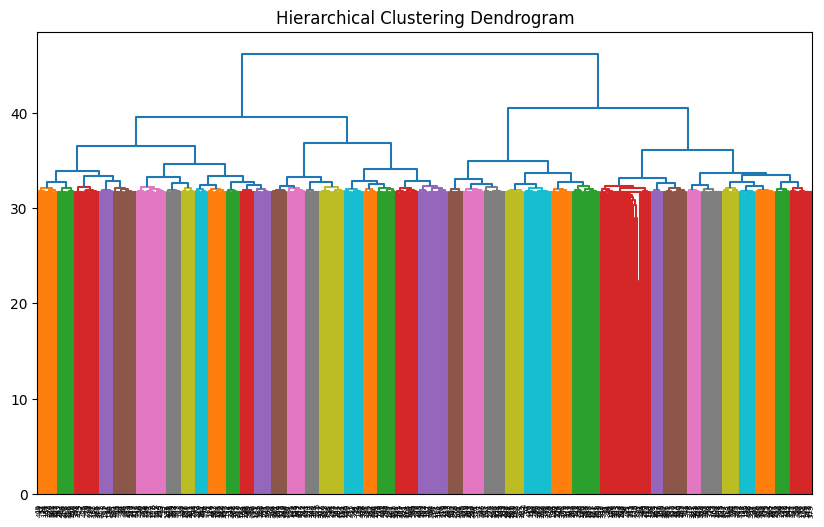

In [12]:
from scipy.cluster.hierarchy import dendrogram, linkage

linked = linkage(X_scaled, method='ward')

plt.figure(figsize=(10,6))
dendrogram(linked)
plt.title("Hierarchical Clustering Dendrogram")
plt.show()


In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

results = []

for seg in df['Segment'].unique():
    seg_df = df[df['Segment'] == seg]

    X_seg = pd.get_dummies(seg_df.drop(['Churn','Segment'], axis=1), drop_first=True)
    y_seg = seg_df['Churn']

    X_train, X_test, y_train, y_test = train_test_split(
        X_seg, y_seg, test_size=0.2, random_state=42
    )

    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred = rf.predict(X_test)

    results.append({
        "Segment": seg,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)
results_df


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


,Segment,Accuracy,Precision,Recall,F1
0,2,0.931034,1.0,0.5,0.666667
1,1,0.941176,1.0,0.5,0.666667
2,0,0.973684,0.0,0.0,0.000000


## Business Recommendations

- **Premium Spenders:** Offer discounts and personalized plans to reduce churn.
- **Budget Conscious:** Promote value packs and flexible pricing.
- **Loyal Long-Term:** Provide loyalty rewards and referral benefits.

Segment-based strategies can significantly improve retention and revenue.
